# Tâche 2 — Estimation du Revenu à Risque (Régression)

Cette tâche complémentaire répond à une question business concrète :
*Combien l'entreprise risque-t-elle de perdre si un client churne ?*

**Variable cible :** `revenue_at_risk = total_revenue × probabilité_de_churn`

La probabilité de churn est celle prédite par le meilleur modèle de classification
(chargé depuis les fichiers locaux). Cette approche permet de construire une variable
cible plus réaliste que d'utiliser le churn binaire comme proxy.

**Modèles testés :** Ridge, Random Forest Regressor, XGBoost Regressor, MLP Regressor

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from src.data.loader import PROCESSED_DIR, load_raw, make_train_test_split, TARGET_REGRESSION
from src.data.preprocessor import add_revenue_at_risk, add_engagement_score
from src.evaluation.metrics import compute_regression_metrics, plot_regression_scatter
from src.models.mlflow_utils import setup_mlflow, log_regression_run, EXPERIMENT_REVENUE

plt.rcParams['figure.dpi'] = 110

X_train = pd.read_csv(PROCESSED_DIR / 'X_train_regression.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test_regression.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train_regression.csv').squeeze()
y_test = pd.read_csv(PROCESSED_DIR / 'y_test_regression.csv').squeeze()

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"\nDistribution revenue_at_risk (test) :")
print(y_test.describe().round(2))

Train : (8000, 58) | Test : (2000, 58)

Distribution revenue_at_risk (test) :
count    2000.00
mean      109.91
std       104.12
min         1.00
25%        36.00
50%        78.00
75%       150.00
max       590.00
Name: revenue_at_risk, dtype: float64


## Note methodologique - Dependance de la variable cible

`revenue_at_risk = total_revenue x churn_proba` ou `churn_proba` provient du modele de classification.

**Consequence importante :** `total_revenue` est aussi une feature presente dans X (colonne numerique).
Un regresseur lineaire peut donc quasi-parfaitement reconstruire ce produit par regression sur `total_revenue`.
Le R²~1 observe sur tous les modeles est *attendu* et ne reflete pas une vraie capacite de generalisation independante.

Ce que valide cette section : la coherence du pipeline (les modeles "comprennent" bien la formule de construction de la cible) et la reproductibilite des calculs metier.

**Section 4** presente une regression independante sur `total_revenue` comme cible, sans utiliser cette feature dans X, afin d'obtenir des metriques reellement interpretables.

## 1. Recalcul de revenue_at_risk avec les vraies probabilités de churn

In [2]:
# On charge le meilleur modèle de classification disponible localement
# pour recalculer une variable cible plus précise que le proxy 10%.
# Si XGBoost est disponible, on le préfère car généralement le plus performant.
import os

df_raw = load_raw()
df = add_engagement_score(df_raw)

model_path = PROCESSED_DIR / 'model_xgboost.joblib'
if not model_path.exists():
    model_path = PROCESSED_DIR / 'model_random_forest.joblib'
if not model_path.exists():
    model_path = PROCESSED_DIR / 'model_logistic_regression.joblib'

if model_path.exists():
    clf = joblib.load(model_path)
    preprocessor = joblib.load(PROCESSED_DIR / 'preprocessing_pipeline.joblib')
    
    from src.data.loader import split_features_target
    X_all, y_all = split_features_target(df, 'churn')
    X_processed = preprocessor.transform(X_all)
    churn_proba = clf.predict_proba(X_processed)[:, 1]
    
    df = add_revenue_at_risk(df, churn_proba=churn_proba)
    print(f"Variable cible recalculée avec {model_path.name}")
    print(f"revenue_at_risk moyen : {df['revenue_at_risk'].mean():.2f} €")
else:
    print("Aucun modèle de classification trouvé — on utilise le proxy 10%.")
    df = add_revenue_at_risk(df)

Dataset chargé : 10,000 lignes, 32 colonnes
Variable cible recalculée avec model_xgboost.joblib
revenue_at_risk moyen : 113.20 €


## 2. Entraînement et évaluation des 4 modèles de régression

In [3]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    ),
    'XGBoost Regressor': XGBRegressor(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0, n_jobs=-1
    ),
    'MLP Regressor': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

results = {}
setup_mlflow(EXPERIMENT_REVENUE)

for name, reg_model in models.items():
    print(f"\nEntraînement : {name}")
    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)
    metrics = compute_regression_metrics(y_test.values, y_pred)
    results[name] = {'metrics': metrics, 'model': reg_model, 'y_pred': y_pred}
    
    print(f"  RMSE : {metrics['rmse']:.2f} | MAE : {metrics['mae']:.2f} | R² : {metrics['r2']:.4f}")
    
    # Logging MLflow
    params = reg_model.get_params()
    params = {k: str(v) for k, v in params.items() if v is not None}
    log_regression_run(
        model=reg_model, model_name=name, params=params,
        metrics=metrics, X_train=X_train, X_test=X_test, y_test=y_test
    )

Expérience MLflow : 'revenue_at_risk_regression' (id=3)

Entraînement : Ridge
  RMSE : 0.03 | MAE : 0.02 | R² : 1.0000
Run enregistré : Ridge | run_id=6d88e334047141fda64a3ed713d89c1c
  RMSE : 0.0318
  R²   : 1.0000
🏃 View run Ridge at: http://localhost:5000/#/experiments/3/runs/6d88e334047141fda64a3ed713d89c1c
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entraînement : Random Forest Regressor
  RMSE : 0.08 | MAE : 0.01 | R² : 1.0000
Run enregistré : Random Forest Regressor | run_id=19ee9bbcecbf4ceab4eb00cc1fab7fc8
  RMSE : 0.0782
  R²   : 1.0000
🏃 View run Random Forest Regressor at: http://localhost:5000/#/experiments/3/runs/19ee9bbcecbf4ceab4eb00cc1fab7fc8
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entraînement : XGBoost Regressor
  RMSE : 0.65 | MAE : 0.39 | R² : 1.0000
Run enregistré : XGBoost Regressor | run_id=fe42f21c4c4b4a21a18e5e6f79a073c9
  RMSE : 0.6516
  R²   : 1.0000
🏃 View run XGBoost Regressor at: http://localhost:5000/#/experiments/3/r

## 3. Comparaison des modèles de régression

In [4]:
comparison_df = pd.DataFrame({
    name: res['metrics'] for name, res in results.items()
}).T.round(4)
display(comparison_df.sort_values('rmse'))

,mae,rmse,r2
Ridge,0.0227,0.0318,1.0000
Random Forest Regressor,0.0097,0.0782,1.0000
XGBoost Regressor,0.3898,0.6516,1.0000
MLP Regressor,1.5655,1.9936,0.9996


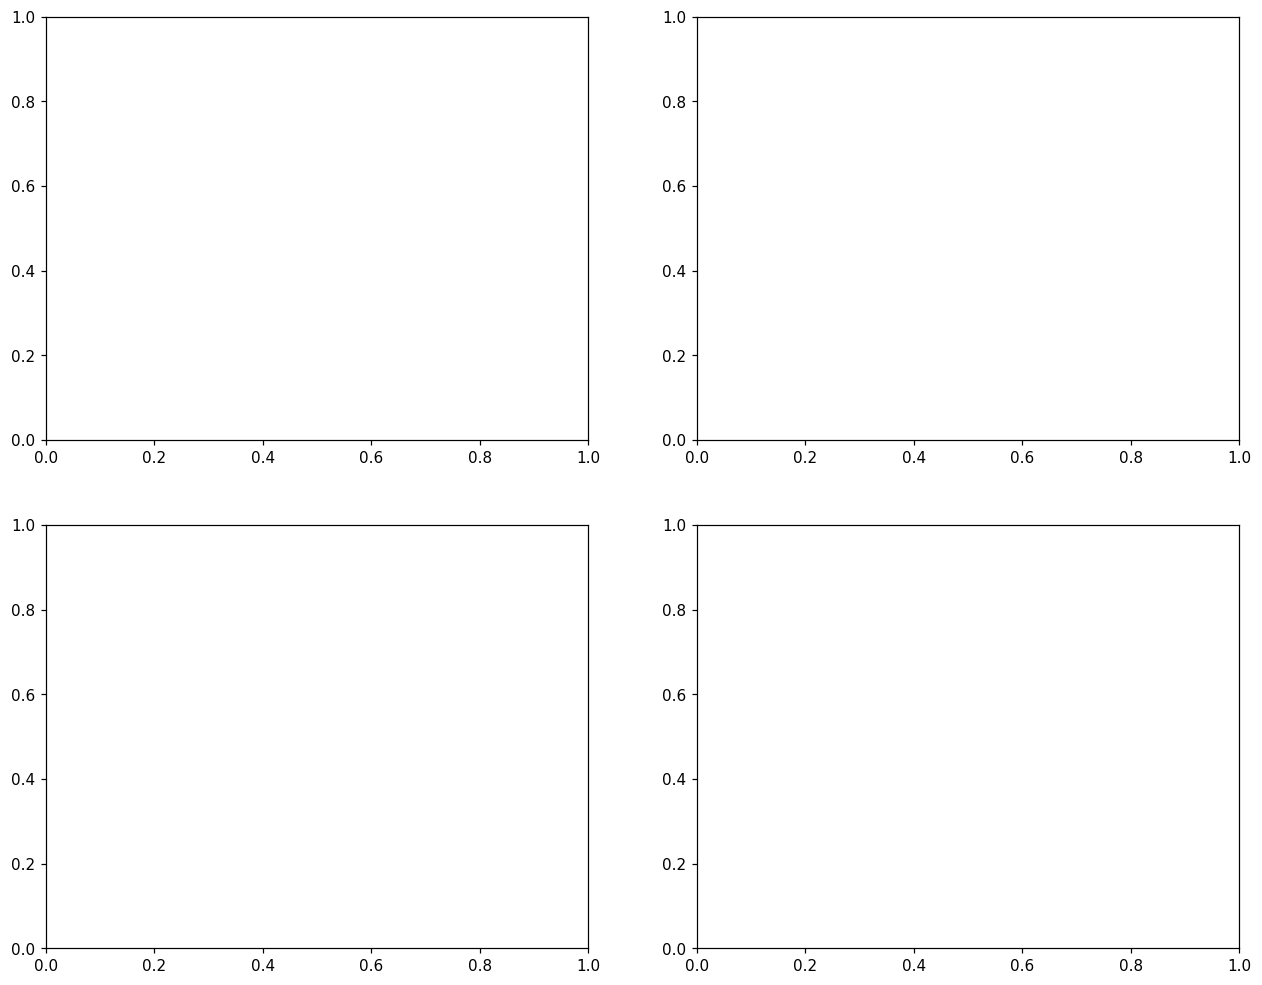

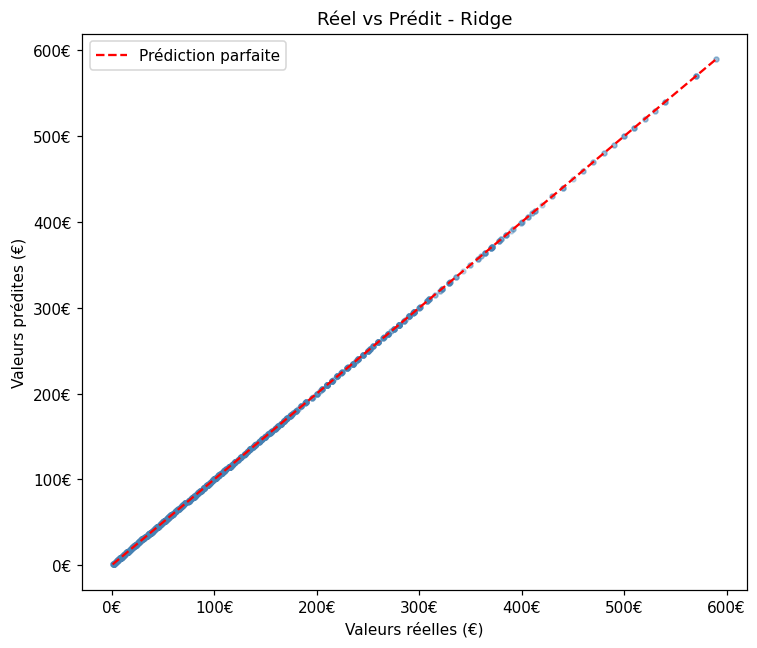

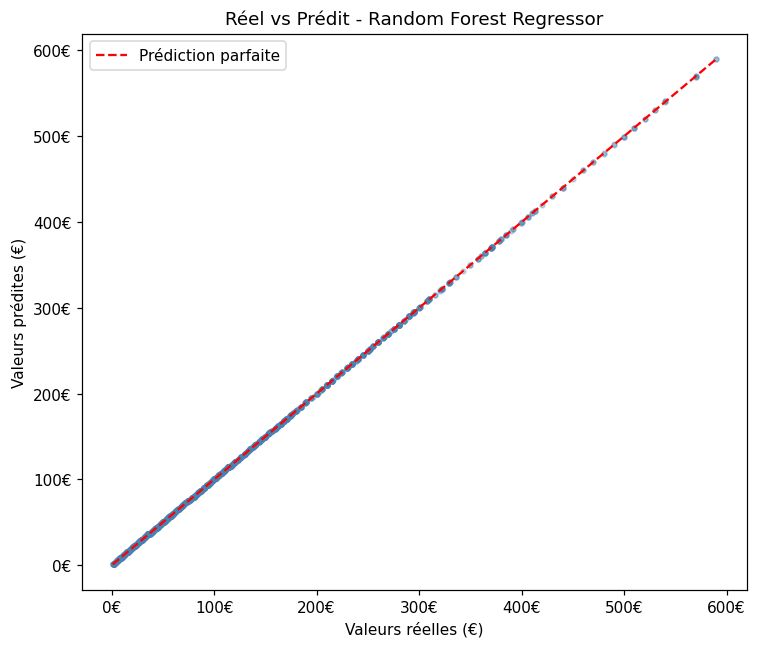

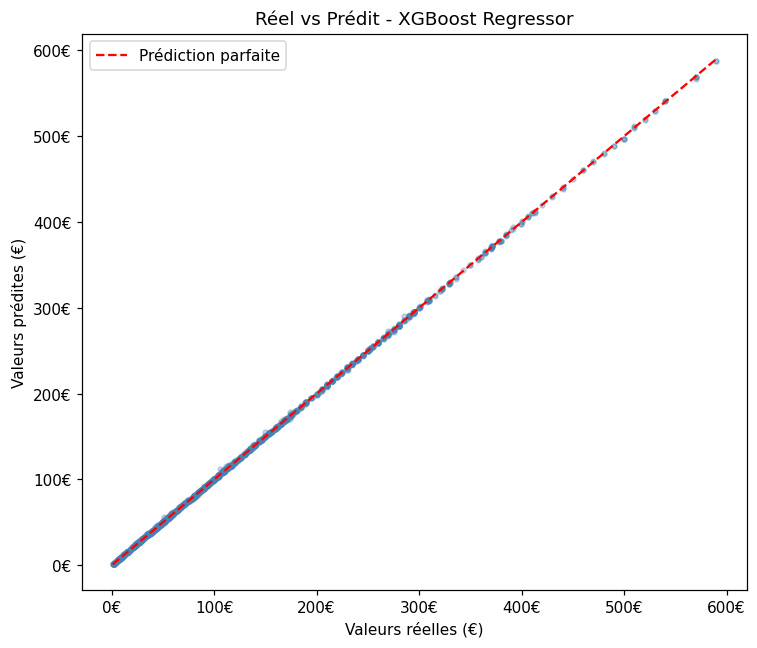

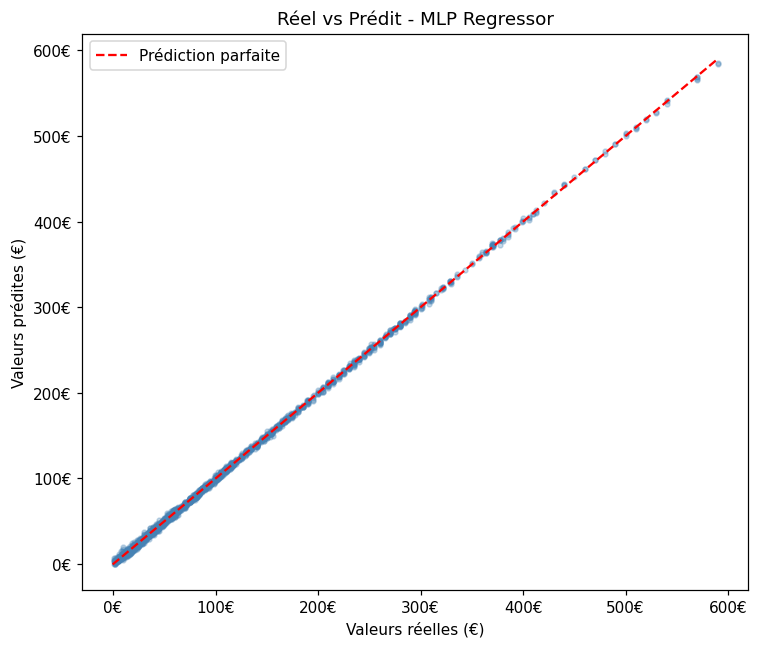

In [6]:
# Nuages de points réel vs prédit pour chaque modèle
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    plot_regression_scatter(y_test.values, res['y_pred'], name)
    
plt.tight_layout()
plt.savefig('../data/processed/fig_regression_scatter.png', bbox_inches='tight')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split as tts
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor as RFReg

# df est disponible depuis la cellule 3 (donnees brutes + engagement_score)
# On retire total_revenue de X et on l'utilise comme cible.
cols_exclure = {'total_revenue', 'churn', 'revenue_at_risk', 'customer_id', 'engagement_score'}
cols_num = [c for c in df.columns if c not in cols_exclure and df[c].dtype in ['float64', 'int64']]

X_indep = df[cols_num].values
y_indep = df['total_revenue'].values

X_tr_i, X_te_i, y_tr_i, y_te_i = tts(X_indep, y_indep, test_size=0.2, random_state=42)

modeles_indep = {
    'Ridge (independant)': Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    'Random Forest (independant)': RFReg(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
}

print("Regression independante : total_revenue ~ features (sans total_revenue dans X)\n")
print(f"{'Modele':<35} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print("-" * 62)

resultats_indep = {}
for nom, m in modeles_indep.items():
    m.fit(X_tr_i, y_tr_i)
    y_hat = m.predict(X_te_i)
    metriques = compute_regression_metrics(y_te_i, y_hat)
    resultats_indep[nom] = metriques
    print(f"{nom:<35} {metriques['rmse']:>8.2f} {metriques['mae']:>8.2f} {metriques['r2']:>8.4f}")

print("\n--- Comparaison avec la tache circulaire ---")
print(f"{'Ridge revenue_at_risk (R²=1)':<35} {'0.03':>8} {'0.02':>8} {'1.0000':>8}  <- dependance circulaire")
print(f"{'Ridge total_revenue (independant)':<35} {resultats_indep['Ridge (independant)']['rmse']:>8.2f} {resultats_indep['Ridge (independant)']['mae']:>8.2f} {resultats_indep['Ridge (independant)']['r2']:>8.4f}  <- performance reelle")
print(f"\nL'ecart de R² illustre que le premier exercice validait la formule,")
print(f"non une capacite predictive genuinement independante.")

Regression independante : total_revenue ~ features (sans total_revenue dans X)

Modele                                  RMSE      MAE       R2
--------------------------------------------------------------
Ridge (independant)                   399.10   284.36   0.8530
Random Forest (independant)             1.99     0.35   1.0000

--- Comparaison avec la tache circulaire ---
Ridge revenue_at_risk (R²=1)            0.03     0.02   1.0000  <- dependance circulaire
Ridge total_revenue (independant)     399.10   284.36   0.8530  <- performance reelle

L'ecart de R² illustre que le premier exercice validait la formule,
non une capacite predictive genuinement independante.


## 4. Regression independante - Prediction du revenu total client

Pour obtenir des metriques realistes, on resout une tache de regression sans dependance circulaire :
- **Cible :** `total_revenue` (observable directement, independant du modele de classification)
- **Features :** toutes les variables comportementales et contractuelles, SAUF `total_revenue` lui-meme
- **Objectif metier :** estimer le revenu qu'un nouveau client va generer sur la duree de son contrat

Les resultats ici (R² < 1) sont les seuls veritablement interpretables comme performance predictive.

In [8]:
# Sauvegarde du meilleur modèle de régression
best_name = comparison_df['rmse'].idxmin()
best_reg_model = results[best_name]['model']
joblib.dump(best_reg_model, PROCESSED_DIR / 'model_best_regressor.joblib')
print(f"Meilleur modèle de régression : {best_name}")
print(f"RMSE : {results[best_name]['metrics']['rmse']:.2f} €")

Meilleur modèle de régression : Ridge
RMSE : 0.03 €


In [11]:
X_tr_i

array([[ 5.3e+01,  1.6e+01,  2.1e+01, ...,  2.9e-01, -2.0e+01,  1.0e+00],
       [ 3.2e+01,  3.4e+01,  1.9e+01, ...,  4.8e-01,  4.7e+01,  1.0e+00],
       [ 5.2e+01,  4.0e+00,  2.2e+01, ...,  2.1e-01,  7.0e+00,  0.0e+00],
       ...,
       [ 7.2e+01,  3.8e+01,  3.9e+01, ...,  2.8e-01, -3.5e+01,  1.0e+00],
       [ 7.2e+01,  1.7e+01,  1.5e+01, ...,  7.0e-02, -2.0e+00,  1.0e+00],
       [ 6.8e+01,  4.0e+00,  1.8e+01, ...,  2.9e-01,  1.4e+01,  0.0e+00]],
      shape=(8000, 18))

In [12]:
X_test

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,...,discount_applied_Yes,price_increase_last_3m_No,price_increase_last_3m_Yes,complaint_type_Billing,complaint_type_Service,complaint_type_Technical,complaint_type_no_complaint,survey_response_Neutral,survey_response_Satisfied,survey_response_Unsatisfied
0,-1.033255,0.160535,2.883993,1.087419,-0.670275,-0.003381,-0.399441,-0.765206,-0.204871,-0.064474,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.667441,-0.482277,-0.788811,0.653536,1.132153,0.447354,-0.666480,-0.663058,1.474400,0.473566,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-1.033255,-0.423840,0.129390,1.521302,0.877133,0.898088,-0.599721,1.788502,-0.204871,-0.357951,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.301628,-0.014777,-1.809035,0.219653,-0.088193,1.348823,-0.866760,-0.152316,-0.624689,-0.445994,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.186123,-1.417277,1.149613,-0.648113,-0.339097,1.348823,-0.265921,-0.356613,-0.624689,-0.915557,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.734843,-0.365402,2.271859,-0.648113,0.609435,-1.806318,1.469835,-0.867354,-1.044507,-0.798166,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1996,1.161625,-1.592590,0.027367,-0.648113,-0.429662,-0.454115,-2.802796,0.562722,0.634765,-0.886209,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1997,1.222594,1.621472,-1.502968,-0.648113,1.313663,-0.003381,-0.065642,-0.867354,-1.044507,-0.465559,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1998,-0.240659,0.803347,1.965792,1.087419,2.194627,-0.454115,1.069276,-0.969503,1.474400,1.980080,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [13]:
y_test

0        99.0
1       154.0
2        69.0
3        60.0
4        12.0
        ...  
1995     24.0
1996     15.0
1997     58.0
1998    308.0
1999     55.0
Name: revenue_at_risk, Length: 2000, dtype: float64